# Exploratory Data Analysis (EDA)
## Dataset: application_train

**Author:** Oknardo Tulung  
**LinkedIn:** https://www.linkedin.com/in/oknardo-tulung/

---

## 📌 Project Overview
This project focuses on performing a comprehensive Exploratory Data Analysis (EDA) on the `application_train` dataset from the Home Credit risk modeling case. The goal is to understand the underlying patterns, data quality, and key drivers related to loan default behavior.

---

## 🎯 Objectives
- Understand the structure and characteristics of the dataset  
- Identify data quality issues (missing values, outliers, inconsistencies)  
- Analyze the distribution of key variables  
- Explore relationships between features and the target variable (loan default)  
- Generate initial insights to support feature engineering and modeling  

---

## 🔍 Analysis Scope
The analysis includes:
- Univariate analysis (distribution of individual variables)  
- Bivariate analysis (relationship with TARGET)  
- Identification of class imbalance  
- Detection of anomalies and outliers  
- Initial business-driven interpretation of features  

---

## 🧠 Key Questions
- What factors differentiate default vs non-default customers?  
- How is income related to credit amount and repayment behavior?  
- Are there strong predictors within external scores (EXT_SOURCE)?  
- What patterns exist in demographic and financial features?  

---

## 🛠 Tools & Libraries
- Python  
- Pandas  
- NumPy  
- Matplotlib  
- Seaborn  

---

## 📊 Output
The output of this EDA will serve as:
- A foundation for feature engineering  
- Input for credit scoring models  
- Business insights for risk assessment  

In [ ]:
# Installation Library
!pip install seaborn


[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
# Importing Library
import pandas as pd
# Setting Pandas Row Display Max
pd.set_option('display.max_rows', None)

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [3]:
# Dataset application_train
application_train = r'D:\Python\Projects\Project Scorecard Model Home Credit Indonesia\home-credit-default-risk\application_train.csv'
df_app_train = pd.read_csv(application_train)

In [4]:
df_app_train.info(verbose=True)

<class 'pandas.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Data columns (total 122 columns):
 #    Column                        Dtype  
---   ------                        -----  
 0    SK_ID_CURR                    int64  
 1    TARGET                        int64  
 2    NAME_CONTRACT_TYPE            str    
 3    CODE_GENDER                   str    
 4    FLAG_OWN_CAR                  str    
 5    FLAG_OWN_REALTY               str    
 6    CNT_CHILDREN                  int64  
 7    AMT_INCOME_TOTAL              float64
 8    AMT_CREDIT                    float64
 9    AMT_ANNUITY                   float64
 10   AMT_GOODS_PRICE               float64
 11   NAME_TYPE_SUITE               str    
 12   NAME_INCOME_TYPE              str    
 13   NAME_EDUCATION_TYPE           str    
 14   NAME_FAMILY_STATUS            str    
 15   NAME_HOUSING_TYPE             str    
 16   REGION_POPULATION_RELATIVE    float64
 17   DAYS_BIRTH                    int64  
 18   DAYS_EMPLOYED

In [5]:
df_app_train['TARGET'].value_counts()

TARGET
0    282686
1     24825
Name: count, dtype: int64

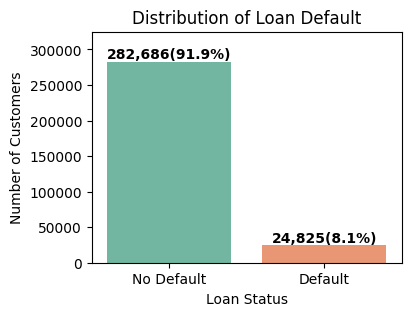

In [6]:
# Plot Loan Distribution
target_df = (
    df_app_train['TARGET']
    .value_counts()
    .rename_axis('Target')
    .reset_index(name='Count')
)
# Percentage
target_df['Percentage'] = target_df['Count'] / target_df['Count'].sum() * 100
# Mapping String
target_df['Target'] = target_df['Target'].map({0: 'No Default', 1: 'Default'})

# Plot
plt.figure(figsize=(4,3))
ax=sns.barplot(
    data=target_df,x='Target',y='Count',
    hue='Target',palette='Set2',legend=False
)

plt.ylim(0, 325000)
plt.title('Distribution of Loan Default')
plt.xlabel('Loan Status')
plt.ylabel('Number of Customers')

# Add labels
for i, row in target_df.iterrows():
    ax.text(i,
        row['Count'],f"{row['Count']:,}({row['Percentage']:.1f}%)",
        ha='center',va='bottom', fontweight='bold'
    )

plt.show()

In [7]:
df_app_train['NAME_CONTRACT_TYPE'].value_counts()

NAME_CONTRACT_TYPE
Cash loans         278232
Revolving loans     29279
Name: count, dtype: int64

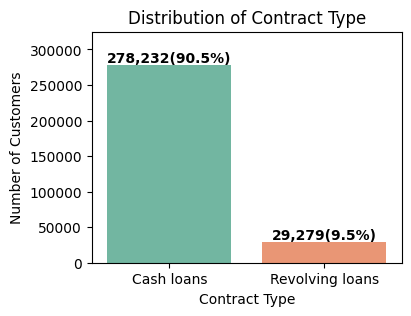

In [8]:
# Plot COntract Type
contract_df = (
    df_app_train['NAME_CONTRACT_TYPE']
    .value_counts()
    .rename_axis('CONTRACT TYPE')
    .reset_index(name='Count')
)
# Percentage
contract_df['Percentage'] = contract_df['Count'] / contract_df['Count'].sum() * 100

# Plot
plt.figure(figsize=(4,3))
ax=sns.barplot(
    data=contract_df,x='CONTRACT TYPE',y='Count',
    hue='CONTRACT TYPE',palette='Set2',legend=False
)

plt.ylim(0, 325000)
plt.title('Distribution of Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Number of Customers')

# Add labels
for i, row in contract_df.iterrows():
    ax.text(i,
        row['Count'],f"{row['Count']:,}({row['Percentage']:.1f}%)",
        ha='center',va='bottom', fontweight='bold'
    )

plt.show()

In [9]:
df_app_train.isnull().sum()

SK_ID_CURR                           0
TARGET                               0
NAME_CONTRACT_TYPE                   0
CODE_GENDER                          0
FLAG_OWN_CAR                         0
FLAG_OWN_REALTY                      0
CNT_CHILDREN                         0
AMT_INCOME_TOTAL                     0
AMT_CREDIT                           0
AMT_ANNUITY                         12
AMT_GOODS_PRICE                    278
NAME_TYPE_SUITE                   1292
NAME_INCOME_TYPE                     0
NAME_EDUCATION_TYPE                  0
NAME_FAMILY_STATUS                   0
NAME_HOUSING_TYPE                    0
REGION_POPULATION_RELATIVE           0
DAYS_BIRTH                           0
DAYS_EMPLOYED                        0
DAYS_REGISTRATION                    0
DAYS_ID_PUBLISH                      0
OWN_CAR_AGE                     202929
FLAG_MOBIL                           0
FLAG_EMP_PHONE                       0
FLAG_WORK_PHONE                      0
FLAG_CONT_MOBILE         